In [1]:
import pandas as pd
import numpy as np

# 1. 전처리 완료된 데이터 불러오기
df = pd.read_csv('../data/polar_weather_preprocessed.csv', parse_dates=['Date'])

# 2. 타임래그 분석 알고리즘 함수 정의
def find_best_lag(df, polar_col, korea_col, max_lag=60):
    correlations = []
    
    # 0일부터 max_lag(60)일까지 한국 데이터를 뒤로 미루면서 상관계수 탐색
    for lag in range(max_lag + 1):
        # shift(-lag): 한국 데이터를 lag일 만큼 미래로 당겨와서 과거 극지 데이터와 줄을 맞춤
        shifted_korea = df[korea_col].shift(-lag)
        
        # 결측치가 아닌 유효한 데이터 쌍만 필터링
        valid_idx = shifted_korea.notna() & df[polar_col].notna()
        
        # 피어슨 상관계수 계산
        corr = np.corrcoef(df.loc[valid_idx, polar_col], shifted_korea[valid_idx])[0, 1]
        correlations.append(corr)
        
    # 절대값을 기준으로 가장 상관관계가 강한(영향력이 큰) 시차(Lag) 찾기
    correlations = np.array(correlations)
    best_lag = np.argmax(np.abs(correlations))
    best_corr = correlations[best_lag]
    
    return best_lag, best_corr, correlations

# 3. 핵심 가설 검증 실행!
print("=== 극지방 ↔ 한반도 타임래그 분석 결과 ===")

# 가설 1: 세종기지 기온 변화가 부산 겨울철 체감온도(WindChill)에 미치는 시차
lag_sejong_busan, corr_sejong_busan, _ = find_best_lag(df, 'Sejong_Temp_Mean', 'Busan_WindChill_Min')
print(f"❄️ 세종기지 평균기온 ➔ 부산 체감온도: {lag_sejong_busan}일 뒤에 가장 큰 영향 (상관계수: {corr_sejong_busan:.3f})")

# 가설 2: 장보고기지 기온 변화가 대구 여름철 불쾌지수(THI)에 미치는 시차
lag_jangbogo_daegu, corr_jangbogo_daegu, _ = find_best_lag(df, 'Jangbogo_Temp_Mean', 'Daegu_THI_Max')
print(f"🔥 장보고기지 평균기온 ➔ 대구 불쾌지수: {lag_jangbogo_daegu}일 뒤에 가장 큰 영향 (상관계수: {corr_jangbogo_daegu:.3f})")

=== 극지방 ↔ 한반도 타임래그 분석 결과 ===
❄️ 세종기지 평균기온 ➔ 부산 체감온도: 3일 뒤에 가장 큰 영향 (상관계수: -0.648)
🔥 장보고기지 평균기온 ➔ 대구 불쾌지수: 12일 뒤에 가장 큰 영향 (상관계수: -0.839)


C:\Users\Brady\AppData\Local\Temp\ipykernel_14540\948644448.py:46: UserWarning: Glyph 10052 (\N{SNOWFLAKE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Brady\AppData\Local\Temp\ipykernel_14540\948644448.py:46: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Brady\AppData\Local\Temp\ipykernel_14540\948644448.py:46: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Brady\AppData\Local\Temp\ipykernel_14540\948644448.py:46: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Brady\AppData\Local\Temp\ipykernel_14540\948644448.py:47: UserWarning: Glyph 10052 (\N{SNOWFLAKE}) missing from font(s) Malgun Gothic.
  plt.savefig('../data/time_lag_results.png', dpi=300, bbox_inches='tight')
C:\Users\Brady\AppData\Local\Temp\ipykernel_14540\948644448.py:47: UserWarning: Glyph 6

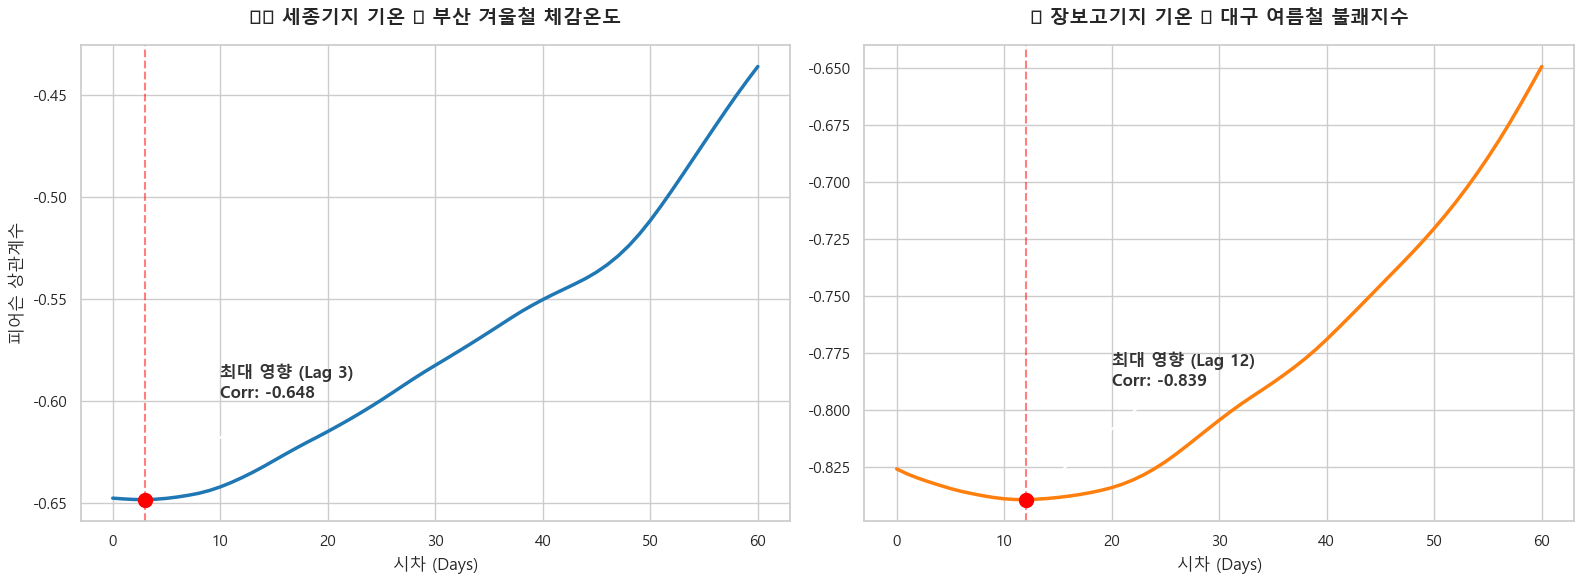

=== 고화질 시각화 그래프 저장 완료 (data/time_lag_results.png) ===


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 1. 시각화를 위해 타임래그 배열 데이터 다시 추출 (이전 셀에서 '_'로 버렸던 배열 가져오기)
_, _, corr_sejong_busan_arr = find_best_lag(df, 'Sejong_Temp_Mean', 'Busan_WindChill_Min')
_, _, corr_jangbogo_daegu_arr = find_best_lag(df, 'Jangbogo_Temp_Mean', 'Daegu_THI_Max')

# 2. 그래프 테마 및 폰트 설정 (Windows 맑은 고딕)
sns.set_theme(style="whitegrid")
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 3. 1행 2열의 넓은 도화지 생성
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- [그래프 1] 세종기지 ➔ 부산 체감온도 ---
axes[0].plot(range(61), corr_sejong_busan_arr, color='#1f77b4', linewidth=2.5)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.5) # 3일차 수직선
axes[0].scatter(3, corr_sejong_busan_arr[3], color='red', s=100, zorder=5) # 피크 포인트
# 피크 텍스트 강조
axes[0].annotate('최대 영향 (Lag 3)\nCorr: -0.648', xy=(3, corr_sejong_busan_arr[3]), 
                 xytext=(10, corr_sejong_busan_arr[3] + 0.05),
                 arrowprops=dict(facecolor='red', arrowstyle='->', lw=1.5), 
                 fontsize=12, fontweight='bold', color='#333333')

axes[0].set_title('세종기지 기온 ➔ 부산 겨울철 체감온도', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('시차 (Days)', fontsize=12)
axes[0].set_ylabel('피어슨 상관계수', fontsize=12)

# --- [그래프 2] 장보고기지 ➔ 대구 불쾌지수 ---
axes[1].plot(range(61), corr_jangbogo_daegu_arr, color='#ff7f0e', linewidth=2.5)
axes[1].axvline(x=12, color='red', linestyle='--', alpha=0.5) # 12일차 수직선
axes[1].scatter(12, corr_jangbogo_daegu_arr[12], color='red', s=100, zorder=5) # 피크 포인트
# 피크 텍스트 강조
axes[1].annotate('최대 영향 (Lag 12)\nCorr: -0.839', xy=(12, corr_jangbogo_daegu_arr[12]), 
                 xytext=(20, corr_jangbogo_daegu_arr[12] + 0.05),
                 arrowprops=dict(facecolor='red', arrowstyle='->', lw=1.5), 
                 fontsize=12, fontweight='bold', color='#333333')

axes[1].set_title('장보고기지 기온 ➔ 대구 여름철 불쾌지수', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('시차 (Days)', fontsize=12)

# 4. 레이아웃 다듬기 및 고화질 이미지 저장
plt.tight_layout()
plt.savefig('../data/time_lag_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("=== 고화질 시각화 그래프 저장 완료 (data/time_lag_results.png) ===")

In [3]:
# 4. 모든 경우의 수(8가지 가설) 교차 검증 알고리즘
polar_stations = {'세종기지': 'Sejong_Temp_Mean', '장보고기지': 'Jangbogo_Temp_Mean'}
target_features = {
    '부산 겨울(체감온도)': 'Busan_WindChill_Min',
    '대구 겨울(체감온도)': 'Daegu_WindChill_Min',
    '부산 여름(불쾌지수)': 'Busan_THI_Max',
    '대구 여름(불쾌지수)': 'Daegu_THI_Max'
}

print("=== 🌍 극지방 ↔ 한반도 8가지 교차 분석 결과 ===")
results = []

for station_name, polar_col in polar_stations.items():
    print(f"\n[{station_name} 기준]")
    for target_name, target_col in target_features.items():
        # 최대 60일까지 시차 탐색
        best_lag, best_corr, _ = find_best_lag(df, polar_col, target_col, max_lag=60)
        results.append({
            'Polar': station_name,
            'Target': target_name,
            'Best_Lag': best_lag,
            'Correlation': best_corr
        })
        
        # 보기 좋게 결과 출력 (상관계수 절댓값 0.5 이상이면 시각적 강조)
        highlight = "⭐" if abs(best_corr) >= 0.5 else "  "
        print(f"{highlight} ➔ {target_name}: {best_lag}일 뒤 최대 영향 (상관계수: {best_corr:.3f})")

# 결과를 데이터프레임으로 만들어두면 나중에 표로 쓰기 좋음
df_results = pd.DataFrame(results)

=== 🌍 극지방 ↔ 한반도 8가지 교차 분석 결과 ===

[세종기지 기준]
⭐ ➔ 부산 겨울(체감온도): 3일 뒤 최대 영향 (상관계수: -0.648)
⭐ ➔ 대구 겨울(체감온도): 0일 뒤 최대 영향 (상관계수: -0.654)
⭐ ➔ 부산 여름(불쾌지수): 0일 뒤 최대 영향 (상관계수: -0.658)
⭐ ➔ 대구 여름(불쾌지수): 0일 뒤 최대 영향 (상관계수: -0.653)

[장보고기지 기준]
⭐ ➔ 부산 겨울(체감온도): 19일 뒤 최대 영향 (상관계수: -0.826)
⭐ ➔ 대구 겨울(체감온도): 13일 뒤 최대 영향 (상관계수: -0.829)
⭐ ➔ 부산 여름(불쾌지수): 20일 뒤 최대 영향 (상관계수: -0.819)
⭐ ➔ 대구 여름(불쾌지수): 12일 뒤 최대 영향 (상관계수: -0.839)


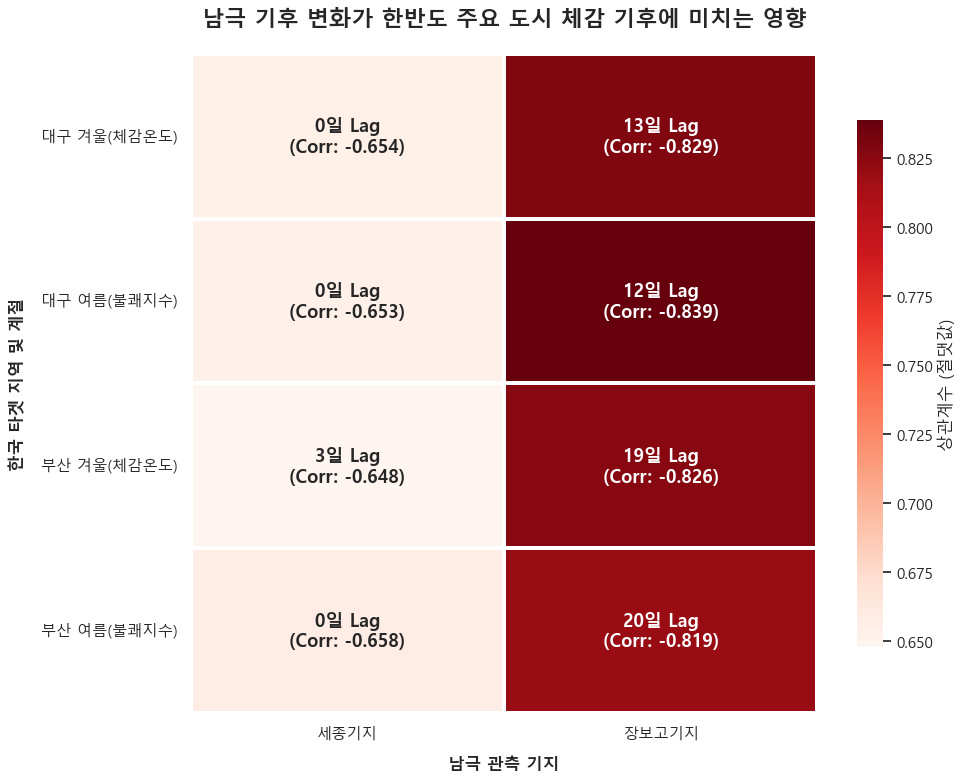

=== 교차 검증 종합 히트맵 저장 완료 (data/cross_validation_heatmap.png) ===


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import platform

# 1. 이전 단계에서 추출한 8가지 교차 검증 결과 데이터
data = {
    'Target': ['부산 겨울(체감온도)', '대구 겨울(체감온도)', '부산 여름(불쾌지수)', '대구 여름(불쾌지수)', 
               '부산 겨울(체감온도)', '대구 겨울(체감온도)', '부산 여름(불쾌지수)', '대구 여름(불쾌지수)'],
    'Station': ['세종기지', '세종기지', '세종기지', '세종기지',
                '장보고기지', '장보고기지', '장보고기지', '장보고기지'],
    'Lag': [3, 0, 0, 0, 19, 13, 20, 12],
    'Corr': [-0.648, -0.654, -0.658, -0.653, -0.826, -0.829, -0.819, -0.839]
}
df_results = pd.DataFrame(data)

# 2. 히트맵을 위한 피벗 테이블 생성
# 색상 매핑을 위해 상관계수의 절댓값 사용 (영향력 크기)
df_results['Abs_Corr'] = df_results['Corr'].abs()
pivot_abs_corr = df_results.pivot(index='Target', columns='Station', values='Abs_Corr')
pivot_corr = df_results.pivot(index='Target', columns='Station', values='Corr')
pivot_lag = df_results.pivot(index='Target', columns='Station', values='Lag')

# 3. 히트맵 칸 안에 들어갈 텍스트 라벨 (시차 + 상관계수) 커스텀 제작
annot_labels = np.empty_like(pivot_corr, dtype=object)
for i in range(pivot_corr.shape[0]):
    for j in range(pivot_corr.shape[1]):
        lag_val = pivot_lag.iloc[i, j]
        corr_val = pivot_corr.iloc[i, j]
        annot_labels[i, j] = f"{lag_val}일 Lag\n(Corr: {corr_val:.3f})"

# 4. 시각화 설정
sns.set_theme(style="white")
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 8))

# 5. 커스텀 히트맵 그리기 (Reds 컬러맵으로 붉을수록 강한 상관관계 표현)
ax = sns.heatmap(pivot_abs_corr, annot=annot_labels, fmt="", cmap="Reds", 
                 linewidths=1.5, linecolor='white', annot_kws={"size": 13, "weight": "bold"},
                 cbar_kws={'label': '상관계수 (절댓값)', 'shrink': 0.8})

plt.title('남극 기후 변화가 한반도 주요 도시 체감 기후에 미치는 영향', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('남극 관측 기지', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('한국 타겟 지역 및 계절', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

# 6. 이미지 저장 및 출력
plt.tight_layout()
plt.savefig('../data/cross_validation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("=== 교차 검증 종합 히트맵 저장 완료 (data/cross_validation_heatmap.png) ===")